In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("zamowienia_messy.csv")

df.head()

,order_id,klient,produkt,kategoria,miasto,ilosc,cena_jednostkowa,data_zamowienia,email
0,1001,Jan Nowak,Mysz,Akcesoria,kraków,2,199.99,13.06.2025,NaN
1,1002,Anna Kowalska,Monitor,elektronika,Kraków,1,399.00 zł,2025-04-09,marta@gmail.com
2,1003,Anna Kowalska,Mysz,Elektronika,WROCŁAW,1,abc,04.01.2025,JAN@WP.PL
3,1004,PIOTR WIŚNIEWSKI,Słuchawki,akcesoria,kraków,1,NaN,05.07.2025,NaN
4,1005,PIOTR WIŚNIEWSKI,Mysz,Elektronika,Gdańsk,1,1 499.00,2025-02-05,anna@gmail.com


In [3]:
print("Rozmiar danych:")
print(df.shape)

print("\nInformacje o danych:")
print(df.info())

print("\nStatystyki:")
print(df.describe())

print("\nBraki danych:")
print(df.isnull().sum())

Rozmiar danych:
(520, 9)

Informacje o danych:
<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   order_id          520 non-null    int64
 1   klient            520 non-null    str  
 2   produkt           520 non-null    str  
 3   kategoria         495 non-null    str  
 4   miasto            495 non-null    str  
 5   ilosc             520 non-null    int64
 6   cena_jednostkowa  457 non-null    str  
 7   data_zamowienia   495 non-null    str  
 8   email             457 non-null    str  
dtypes: int64(2), str(7)
memory usage: 36.7 KB
None

Statystyki:
          order_id       ilosc
count   520.000000  520.000000
mean   1252.296154    1.678846
std     144.135844    1.303151
min    1001.000000   -1.000000
25%    1129.750000    1.000000
50%    1253.500000    1.000000
75%    1376.250000    2.000000
max    1500.000000    5.000000

Braki danych:
order_

In [4]:
print("Klienci:")
print(df["klient"].value_counts())

print("\nProdukty:")
print(df["produkt"].value_counts())

print("\nKategorie:")
print(df["kategoria"].value_counts())

print("\nMiasta:")
print(df["miasto"].value_counts())

Klienci:
klient
Anna Kowalska            107
anna kowalska             58
Krzysztof Kamiński        56
katarzyna lewandowska     55
Marta Wójcik              55
 Magdalena Dąbrowska      54
  Jan Nowak               53
Tomasz Zieliński          45
PIOTR WIŚNIEWSKI          37
Name: count, dtype: int64

Produkty:
produkt
Mysz          62
MYSZ          56
Monitor       55
Laptop        53
Webcam        53
monitor       50
Słuchawki     49
Pendrive      49
laptop        48
Klawiatura    45
Name: count, dtype: int64

Kategorie:
kategoria
Akcesoria      90
akcesoria      90
elektronika    87
Akcesoria      82
Elektronika    80
ELEKTRONIKA    66
Name: count, dtype: int64

Miasta:
miasto
warszawa     61
kraków       60
Gdańsk       58
WROCŁAW      57
 Warszawa    57
Warszawa     54
Łódź         53
Poznań       53
Kraków       42
Name: count, dtype: int64


In [5]:
# Problemy z jakością danych

# 1. Są braki danych, np. w email, miasto, kategoria albo cena_jednostkowa.
# 2. Są duplikaty wierszy.
# 3. Teksty są zapisane nierówno, np. spacje i różna wielkość liter.
# 4. Daty są w różnych formatach.
# 5. Cena jest tekstem, a powinna być liczbą.
# 6. Mogą być błędne ilości, np. 0 albo liczby ujemne.
# 7. Niektóre emaile mogą być niepoprawne.

In [6]:
# usuwamy duplikaty
df = df.drop_duplicates()

# czyszczenie tekstow: spacje i wielkość liter
df["klient"] = df["klient"].str.strip().str.title()
df["produkt"] = df["produkt"].str.strip().str.title()
df["kategoria"] = df["kategoria"].str.strip().str.lower()
df["miasto"] = df["miasto"].str.strip().str.title()

# zamiana daty na typ datetime
df["data_zamowienia"] = pd.to_datetime(
    df["data_zamowienia"],
    errors="coerce",
    format="mixed",
    dayfirst=True
)

# zmiana ceny na liczbę
df["cena_jednostkowa"] = pd.to_numeric(
    df["cena_jednostkowa"],
    errors="coerce"
)

# usuniecie wierszy bez ceny albo daty
df = df.dropna(subset=["cena_jednostkowa", "data_zamowienia"])

# uzupelnienie brakow w mniej ważnych kolumnach
df["miasto"] = df["miasto"].fillna("Unknown")
df["kategoria"] = df["kategoria"].fillna("unknown")
df["email"] = df["email"].fillna("brak_emaila")

# usuniecie blednych ilosci, czyli 0 i liczby ujemne
df = df[df["ilosc"] > 0]

df.head()

,order_id,klient,produkt,kategoria,miasto,ilosc,cena_jednostkowa,data_zamowienia,email
0,1001,Jan Nowak,Mysz,akcesoria,Kraków,2,199.99,2025-06-13,brak_emaila
7,1008,Piotr Wiśniewski,Laptop,elektronika,Poznań,3,199.99,2025-05-24,anna@gmail.com
9,1010,Anna Kowalska,Mysz,elektronika,Warszawa,1,199.99,2025-10-05,tomasz@interia.pl
10,1011,Tomasz Zieliński,Pendrive,elektronika,Wrocław,1,2999.00,2025-09-28,marta@gmail.com
12,1013,Anna Kowalska,Mysz,akcesoria,Gdańsk,2,199.99,2025-05-23,anna@gmail.com


In [7]:
# wartość całego zamówienia
df["wartosc_zamowienia"] = df["ilosc"] * df["cena_jednostkowa"]

# wyciągamy rok, miesiąc i nazwę dnia z daty
df["rok"] = df["data_zamowienia"].dt.year
df["miesiac"] = df["data_zamowienia"].dt.month
df["nazwa_dnia"] = df["data_zamowienia"].dt.day_name()

# sprawdzenie czy email wygląda poprawnie
df["email_poprawny"] = df["email"].str.contains(
    r"^[^@\s]+@[^@\s]+\.[^@\s]+$",
    regex=True
)

df.head()

,order_id,klient,produkt,kategoria,miasto,ilosc,cena_jednostkowa,data_zamowienia,email,wartosc_zamowienia,rok,miesiac,nazwa_dnia,email_poprawny
0,1001,Jan Nowak,Mysz,akcesoria,Kraków,2,199.99,2025-06-13,brak_emaila,399.98,2025,6,Friday,False
7,1008,Piotr Wiśniewski,Laptop,elektronika,Poznań,3,199.99,2025-05-24,anna@gmail.com,599.97,2025,5,Saturday,True
9,1010,Anna Kowalska,Mysz,elektronika,Warszawa,1,199.99,2025-10-05,tomasz@interia.pl,199.99,2025,10,Sunday,True
10,1011,Tomasz Zieliński,Pendrive,elektronika,Wrocław,1,2999.00,2025-09-28,marta@gmail.com,2999.00,2025,9,Sunday,True
12,1013,Anna Kowalska,Mysz,akcesoria,Gdańsk,2,199.99,2025-05-23,anna@gmail.com,399.98,2025,5,Friday,True


In [8]:
# laczna wartość zamówień w każdym miesiącu
wartosc_miesiac = df.groupby("miesiac")["wartosc_zamowienia"].sum()

print("Łączna wartość zamówień w każdym miesiącu:")
print(wartosc_miesiac)

# top 5 klientów
top_5_klientow = (
    df.groupby("klient")["wartosc_zamowienia"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

print("\nTop 5 klientów:")
print(top_5_klientow)

# srednia wartość zamówienia w każdej kategorii
srednia_kategoria = df.groupby("kategoria")["wartosc_zamowienia"].mean()

print("\nŚrednia wartość zamówienia w każdej kategorii:")
print(srednia_kategoria)

Łączna wartość zamówień w każdym miesiącu:
miesiac
1     15264.35
2     48611.35
3     18931.83
4     59765.41
5     18510.86
6     21778.36
7     12665.33
8     41234.41
9     39730.38
10    26755.42
11      957.97
12     5998.00
Name: wartosc_zamowienia, dtype: float64

Top 5 klientów:
klient
Anna Kowalska            126204.54
Krzysztof Kamiński        52898.94
Katarzyna Lewandowska     36995.19
Tomasz Zieliński          23151.76
Magdalena Dąbrowska       23019.43
Name: wartosc_zamowienia, dtype: float64

Średnia wartość zamówienia w każdej kategorii:
kategoria
akcesoria      1978.471702
elektronika    1613.341948
Name: wartosc_zamowienia, dtype: float64


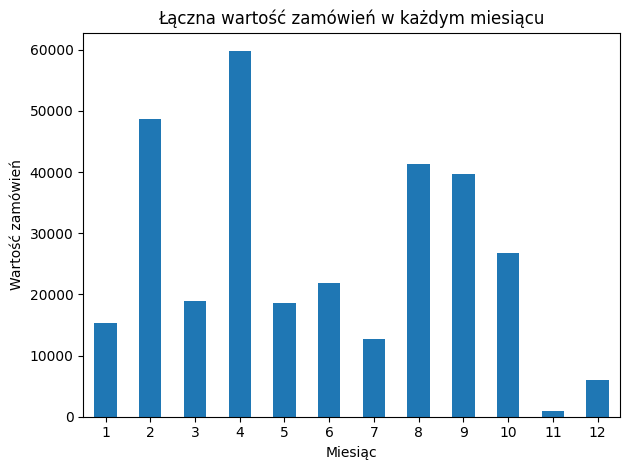

In [9]:
wartosc_miesiac.plot(kind="bar")

plt.title("Łączna wartość zamówień w każdym miesiącu")
plt.xlabel("Miesiąc")
plt.ylabel("Wartość zamówień")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
df.to_csv("zamowienia_clean.csv", index=False)

print("Gotowe! Plik zapisany jako zamowienia_clean.csv")

Gotowe! Plik zapisany jako zamowienia_clean.csv
